# Calibrate an objective pair

Measure focus and X/Y offsets between a reference and target objective. Complete limits and orientation first.

Every Measure cell is safe to run again. It first checks that the expected objective is in place — if not, it refuses without losing anything, so you can switch back and simply run the cell again. Once the check passes, the cell replaces its own previous measurement and anything that was computed from it.

## Configure

Edit the four values below for your own run, then execute the cell:

- `acquisition_name` names the objective pair you are about to measure, for example `"10x-20x"`. Each pair gets its own folder inside the session.
- `session_id` names the calibration session that collects all pairs measured in one sitting. A date plus a short label works well.
- `backlash_rounds` controls how many motorized X/Y backlash take-up rounds run before each acquisition. Use `0` to disable correction, or any whole number `1`, `2`, and so on. The default is `5`.
- `reference_slot` is the turret slot of the reference objective — the objective every other objective is measured against. Keep it the same for every pair in one session.

In LAS X, select the Navigator Expert job you will use and put in the reference objective. Keep that job selected for the whole run; between steps you change only the objective.

In [8]:
import _bootstrap
from navigator_expert.calibration.core import adopt, objective_pair

session = objective_pair.start_session(
    acquisition_name="10x-20x",
    session_id="2026-07-14_calibration_1",
    reference_slot=1,
    backlash_rounds=5,
)

Using active Navigator Expert job: HiRes
Configured reference objective: slot 1 — HC PL APO CS2    10x/0.40 DRY


## Measure 1: reference focus

With the reference objective: focus using Z-wide, keep Z-galvo at 0, disable Set Focus, and configure a manual z-stack (for example 80 um with 1 um steps). Use a pixel size the target objective can match.

Two settings matter here. The calibration records focus as a Z-wide position, so the Z-galvo must sit at 0 — any galvo offset would silently mix into the measured value. And the z-stack should comfortably bracket the focal plane: the focus peak must fall inside the stack, or the fit refuses and asks you to refocus and re-run.

Reference objective: slot 1 — HC PL APO CS2    10x/0.40 DRY


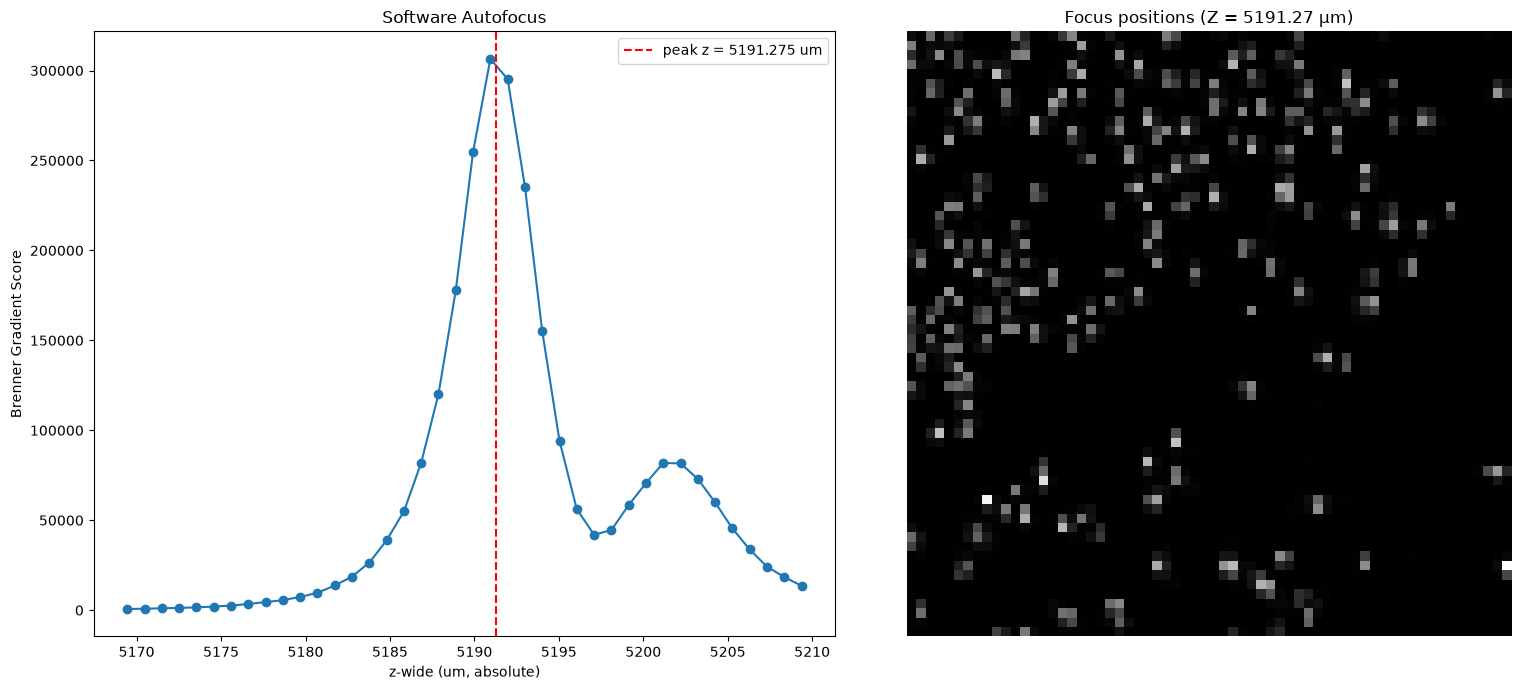

In [9]:
objective_pair.measure_parfocality_reference(session);

## Measure 2: target focus

Switch only to the target objective and match the reference pixel size. Do not change the job, Z-wide, Z-galvo, or other acquisition settings.

This cell decides which objective counts as the target. If you ran it with the wrong objective, switch to the intended one and run it again — the wrong measurement is discarded and the pair is redefined.

Target objective: slot 2 — HC PL APO CS2    20x/0.75 DRY


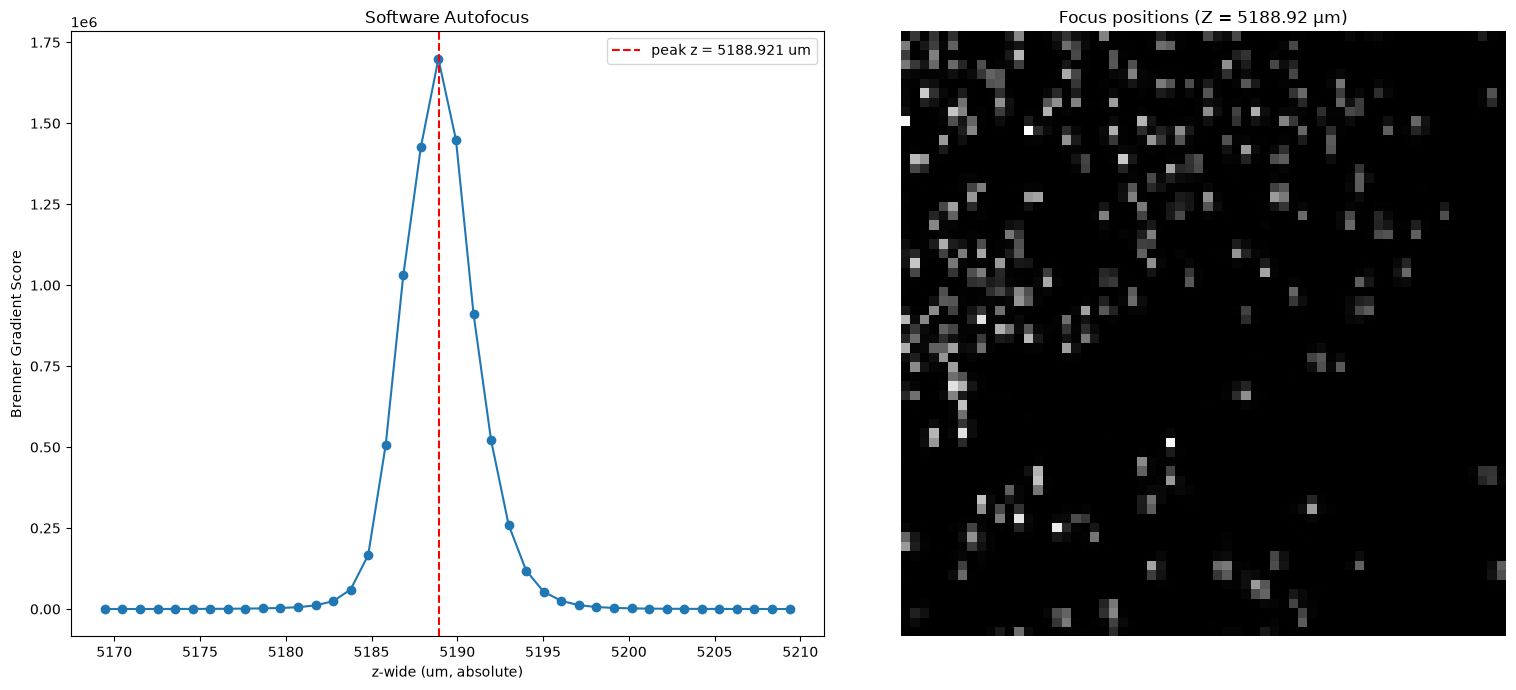

Z-wide translation from HC PL APO CS2    10x/0.40 DRY to HC PL APO CS2    20x/0.75 DRY: -2.35 µm


In [10]:
objective_pair.measure_parfocality_target(session);

## Measure 3: reference X/Y

Switch back to the reference objective. Remove the z-stack, keep Z-galvo at 0, and use the same job and pixel size for both X/Y images.

The X/Y offset is found by matching the reference and target images against each other pixel by pixel. That comparison only means anything when both images are acquired at exactly the same physical pixel size — otherwise the same feature lands a different number of pixels away in each image.

In [11]:
objective_pair.measure_parcentricity_reference(session);

Reference objective: slot 1 — HC PL APO CS2    10x/0.40 DRY
Reference XY image acquired.  pixel size = 0.2839 um


## Measure 4: target X/Y

Switch only to the target objective. Do not move motorized X/Y; match the reference image's physical pixel size exactly.

If the summary reports WEAK VOTE, the registration methods could not agree on the shift and nothing was saved. That usually means the two images do not share enough detail. Move to a more textured spot with the reference objective, refocus, and re-run Measure 3 and Measure 4.

Use the alignment plots below to confirm by eye that the reference and corrected target images overlap before continuing to Save and Adopt.

Target objective: slot 2 — HC PL APO CS2    20x/0.75 DRY


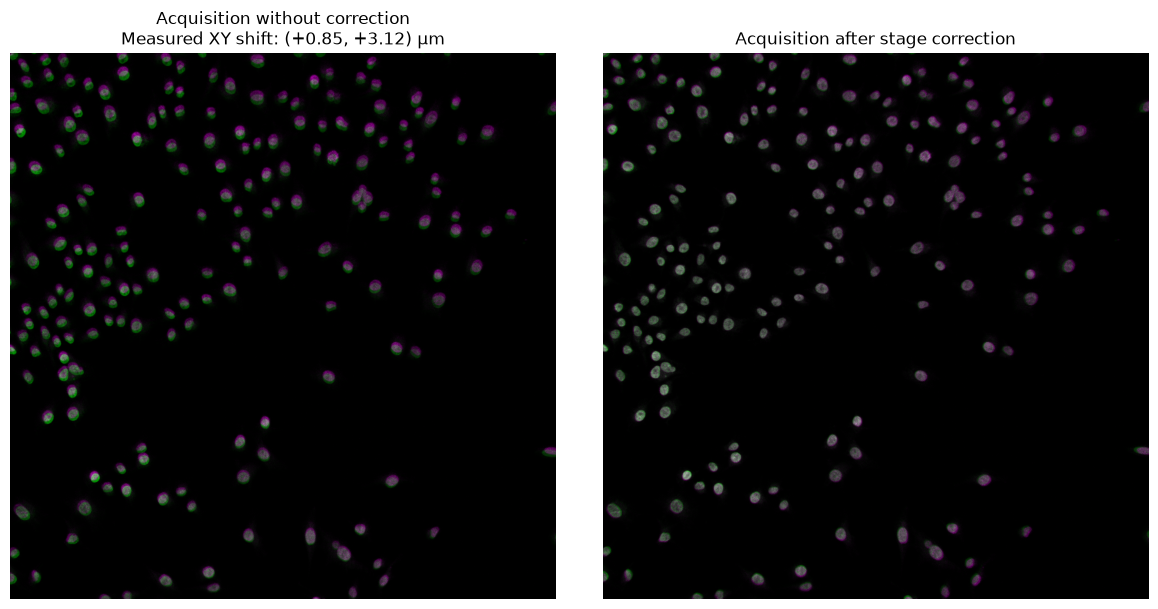

Objective pair calibration: OK -- session calibration updated

  Pair:           slot 1 (HC PL APO CS2    10x/0.40 DRY) -> slot 2 (HC PL APO CS2    20x/0.75 DRY)
  Voting:         trusted (3/4)
  Image shift:    (+0.85, +3.12) um
  Translation XY: (-6.17, +24.20) um
  Translation Z:  -2.35 um

  Session calibration updated:
    C:\ProgramData\zmart-microscopy\leica\stellaris5_y42h93\navigator_expert\calibration\2026-07-14_calibration_1\10x-20x\calibration.json

  Run the adopt cell below to make it active.


In [12]:
summary = objective_pair.measure_parcentricity_target_and_save(session)

## Save and Adopt

This saves the completed notebook, verifies its X/Y measurement output, then publishes the calibration.

To calibrate another pair (for example 10x-40x), go back to Configure, change only `acquisition_name`, and run the notebook again from there with the same reference objective. Pairs that share the reference combine on their own: once 10x-20x and 10x-40x are measured, the 20x-40x offset follows from them without a separate measurement. Adopting again after each pair is fine — adoption always publishes everything measured in the session so far.

In [13]:
# Save and Adopt
adopted = _bootstrap.NOTEBOOK.save_and_adopt(
    lambda notebook: adopt.adopt_calibration(session, notebook_paths=[notebook])
)
print(f"Calibration adopted: {adopted['calibration_path']}")

Calibration adopted: C:\ProgramData\zmart-microscopy\leica\stellaris5_y42h93\navigator_expert\calibration\2026-07-21T16-04-38-387106Z\calibration.json
